# Retail Customer Churn Analysis

## Python Data Analytics Portfolio Project 

### Objective
Analyze customer behaviour to understand why customers churn and 
identify actionable opportunities for customer retention 

### Tools Used 
-Python 
-Pandas 
-Numpy
-Matplotlib 
-Seaborn 

### Dataset 
Retail Customer dataset containing 100,000
customer records 


## 1. Business Problem

Customer churn is an important challenge for retail businesses because
losing existing customers can reduce repeat purchases and revenue.

The objective of this analysis is to understand:

- How large is the churn problem?
- Which customer groups have higher churn?
- What customer behaviours are associated with churn?
- Does recency affect churn?
- Does cart abandonment relate to churn?
- How do loyalty and engagement differ between churned and retained customers?
- Which customers should be prioritized for retention?

In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from IPython.display import display
pd.set_option("display.max_columns",50)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")

sns.set_theme(style="whitegrid")

## 2. Loading The Dataset
First, we will Load the customer dataset and inspect it's structure. 

In [10]:
df = pd .read_csv("retail_customer_churn_100K.csv")
df

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,"2,108.80",189,27,0.38,0.13,0.42,33,35.50,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,"3,843.06",277,68,0.51,0.06,0.07,68,49.50,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.00,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,"1,960.79",89,93,0.66,0.31,0.13,93,59.00,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.50,High,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C099996,25-34,Male,Central,Loyal,In-Store,8,363.84,"2,596.84",191,54,0.72,0.10,0.30,67,40.00,Low,0
99996,C099997,25-34,Other,West,New,In-Store,2,195.94,337.17,104,5,0.59,0.05,0.28,51,38.50,Low,0
99997,C099998,18-24,Male,Central,Loyal,Mobile App,2,40.53,93.39,150,11,0.44,0.63,0.31,59,66.00,Low,0
99998,C099999,25-34,Male,Central,VIP,Online,12,173.99,"2,476.75",201,70,0.70,0.39,0.67,72,36.00,Medium,0


In [11]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])
display(df.head())
      

Number of rows: 100000
Number of columns: 18


,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,"2,108.80",189,27,0.38,0.13,0.42,33,35.50,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,"3,843.06",277,68,0.51,0.06,0.07,68,49.50,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.00,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,"1,960.79",89,93,0.66,0.31,0.13,93,59.00,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.50,High,1


## 3 Understanding the Dataset 

Before performing analysis, we need to understand the strucure data types and availabel variables.

In [12]:
df.info()

df.describe()

print(df.columns .tolist())

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   age_group              100000 non-null  object 
 2   gender                 100000 non-null  object 
 3   region                 100000 non-null  object 
 4   customer_segment       100000 non-null  object 
 5   preferred_channel      100000 non-null  object 
 6   purchase_frequency     100000 non-null  int64  
 7   avg_order_value        100000 non-null  float64
 8   total_spent            100000 non-null  float64
 9   recency_days           100000 non-null  int64  
 10  website_visits         100000 non-null  int64  
 11  discount_usage_rate    100000 non-null  float64
 12  email_open_rate        100000 non-null  float64
 13  cart_abandonment_rate  100000 non-null  float64
 14  loyalty_score          100000 non-nul

np.int64(0)

### Data Cleaning
Before analyzing customer behaviour , we will check:

-Missing Values
-Duplicates records
-Duplicate Customer Id's
-Data types 
-Inavlid numerical values 

In [13]:
print("Missing values:")
display(df.isnull().sum())

Missing values:


customer_id              0
age_group                0
gender                   0
region                   0
customer_segment         0
preferred_channel        0
purchase_frequency       0
avg_order_value          0
total_spent              0
recency_days             0
website_visits           0
discount_usage_rate      0
email_open_rate          0
cart_abandonment_rate    0
loyalty_score            0
engagement_score         0
churn_risk               0
churn_flag               0
dtype: int64

In [14]:
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [15]:
print("Duplicate Customer ID's:",df["customer_id"].duplicated().sum())

Duplicate Customer ID's: 0


### Data Quality Observation

The dataset does not contain missing values or duplicate customer records.Therefore,no imputation or duplicate removal was required.
The dataset is ready for exploratory analysis. 

## Key Performance Indicators 
Before exploring individual variables, we will establish the overall customer and churn picture.

In [16]:
total_customers= df["customer_id"].nunique()
churned_customers=df["churn_flag"].sum()
retained_customers = total_customers - churned_customers
churn_rate = churned_customers/ total_customers*100


print("Total Customers:" ,total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)
print("Churn Rate:",round(churn_rate,2),"%")     

Total Customers: 100000
Churned Customers: 46224
Retained Customers: 53776
Churn Rate: 46.22 %


## Overall Churn Distribution 

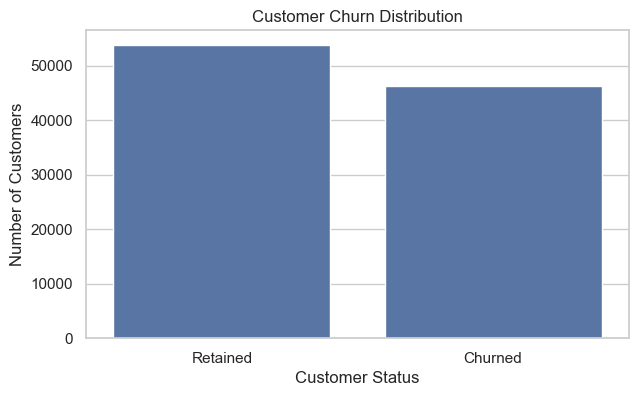

In [17]:
churn_counts= df["churn_flag"].value_counts()
plt.figure(figsize=(7,4))

sns.barplot(
    x=["Retained","Churned"],
    y=[churn_counts[0],churn_counts[1]])

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()



### Insight 
The dataset shows a churn rate approximately 46%.

This means churn is a significant business problem rather than a small proprtyion of customers.

### Business Implication 
The company should focus o identifiying behavioural signals that appear before customers churn so that retention actions can be taken earlier.

## Churn Rate By Customer Segment 

In [18]:
segment_churn=(df.groupby("customer_segment")["churn_flag"] .mean()
               .sort_values(ascending=False)*100
              )
display(segment_churn)

customer_segment
VIP         46.67
New         46.32
Returning   45.98
Loyal       45.93
Name: churn_flag, dtype: float64

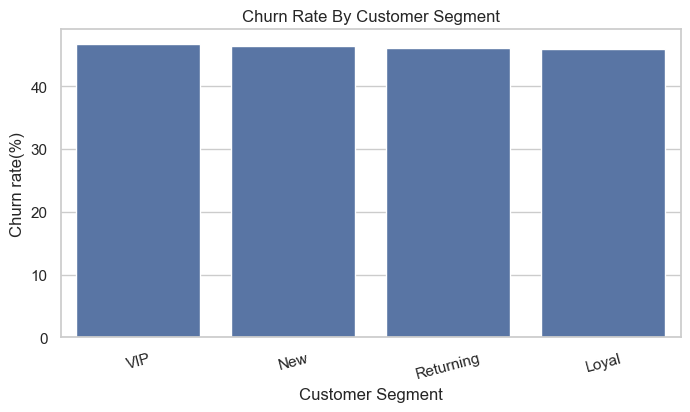

In [19]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=segment_churn.index,
    y=segment_churn.values,
)
plt.title("Churn Rate By Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn rate(%)")
plt.xticks(rotation=15)

plt.show()

### Insight
Churn rate diffres across customer segments,but the differences are relatively smaller than the diffrences observed in behavioural variables such as recency and cart abandonment.
### Business Implication 
customer segment alone should not be used as the primary retention criterion.
Behavioural indicators can provide more useful signals for identifying individual customers at risk.

## Churn Rate By Region 

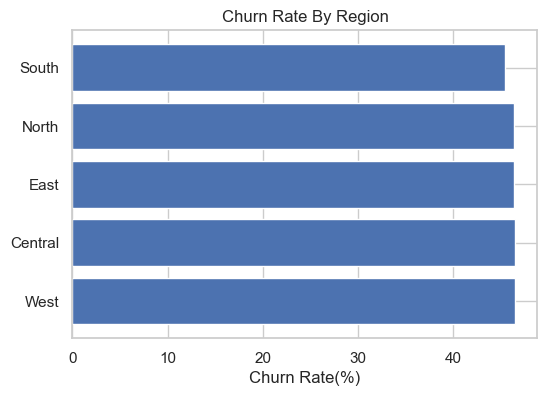

In [20]:
region_churn=(
    df.groupby("region")["churn_flag"].mean()
    .sort_values(ascending=False)*100
)
plt.figure(figsize=(6,4))
plt.barh(
    region_churn.index,
    region_churn.values
)

plt.title("Churn Rate By Region")
plt.xlabel("Churn Rate(%)")
plt.show()



### Insight
Churn rates vary across regions , but the differences are relatively moderate.
This suggests that regional cahrecteristics alone may not explain the majority of customer churn.

### Business Implication 
Instead of applying the same retention strategy to an entire region ,
the business should combine geography with customer behaviour.

## Impact Of Customer Recency On Churn 

Recency represent the number of days since a customer's last purchase.To make the pattern easier to understand ,customers will be grouped into different recency buckets.


In [21]:
df["recency_buckets"]=pd.cut(
    df["recency_days"],
    bins=[-1,30,90,180,270,float("inf")],
labels=["0-30 days","31-90 days","91-180 days","181-270 days","271+ Days"])


In [22]:
recency_churn=(
    df.groupby("recency_buckets",observed=False)
    ["churn_flag"].mean()*100
)


plt.figure(figsize=(9,5))

plt.plot(
    recency_churn.index.astype(str),
    recency_churn.values,
    marker="o"
)

plt.title("Churn Rate By Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Churn Rate(%)")

plt.grid(True)
plt.tight_layout()
plt.show()

### Insight
The analysis shows a clear relationship between customer recency and churn. As the number of days since a customer's last purchase increases, the churn rate also increases.
This indicates that longer periods of customer inactivity are associated with a higher risk of churn, making recency an important behavioural indicator for retention analysis.
### Business Implication
Recency can be used as an early warning indicator for customer churn.
The business could use different retention approaches based on customer inactivity:
- Recently inactive customers: Reminder or re-engagement communication
- Moderately inactive customers: Personalized offers or product recommendations
- Long-term inactive customers: Win-back campaigns

The effectiveness and timing of these interventions should be validated through controlled business experiments.

## Cart Abandonent and Customer Churn 

In [37]:
df["Cart_abandonment_bucket"]=pd.cut(
    df["cart_abandonment_rate"],
    bins=[-0.01,0.20,0.40,0.60,0.80,1.01],
    labels=[
        "0-20%",
        "21-40%",
        "41-60%",
        "61-80%",
        "81-100%"
        ]
        )
df

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag,recency_buckets,Cart_abandonment_bucket,loyalty_bucket,engagement_bucket
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,"2,108.80",189,27,0.38,0.13,0.42,33,35.50,Medium,1,181-270 days,41-60%,21-40,21-40
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,"3,843.06",277,68,0.51,0.06,0.07,68,49.50,Medium,1,271+ Days,0-20%,61-80,41-60
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.00,High,1,271+ Days,41-60%,61-80,21-40
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,"1,960.79",89,93,0.66,0.31,0.13,93,59.00,Low,0,31-90 days,0-20%,81-100,41-60
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.50,High,1,181-270 days,41-60%,0-20,21-40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,C099996,25-34,Male,Central,Loyal,In-Store,8,363.84,"2,596.84",191,54,0.72,0.10,0.30,67,40.00,Low,0,181-270 days,21-40%,61-80,21-40
99996,C099997,25-34,Other,West,New,In-Store,2,195.94,337.17,104,5,0.59,0.05,0.28,51,38.50,Low,0,91-180 days,21-40%,41-60,21-40
99997,C099998,18-24,Male,Central,Loyal,Mobile App,2,40.53,93.39,150,11,0.44,0.63,0.31,59,66.00,Low,0,91-180 days,21-40%,41-60,61-80
99998,C099999,25-34,Male,Central,VIP,Online,12,173.99,"2,476.75",201,70,0.70,0.39,0.67,72,36.00,Medium,0,181-270 days,61-80%,61-80,21-40


In [24]:
cart_churn=(
    df.groupby(
        "Cart_abandonment_bucket",
        observed=False
    )["churn_flag"].mean()*100
)

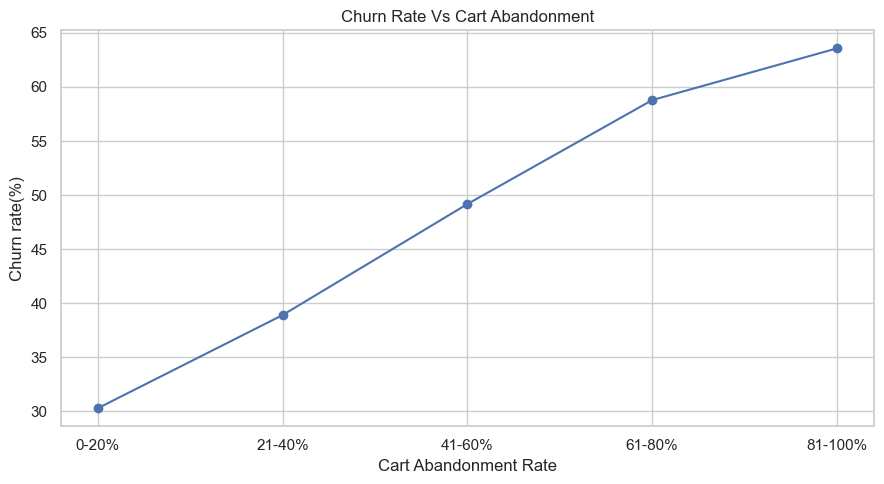

In [25]:
plt.figure(figsize=(9,5))

plt.plot(
    cart_churn.index.astype(str),
    cart_churn.values,
    marker="o"
)

plt.title("Churn Rate Vs Cart Abandonment")
plt.xlabel("Cart Abandonment Rate")
plt.ylabel("Churn rate(%)")

plt.grid(True)
plt.tight_layout()
plt.show()

## Purchase Frequency VS Total Spend 

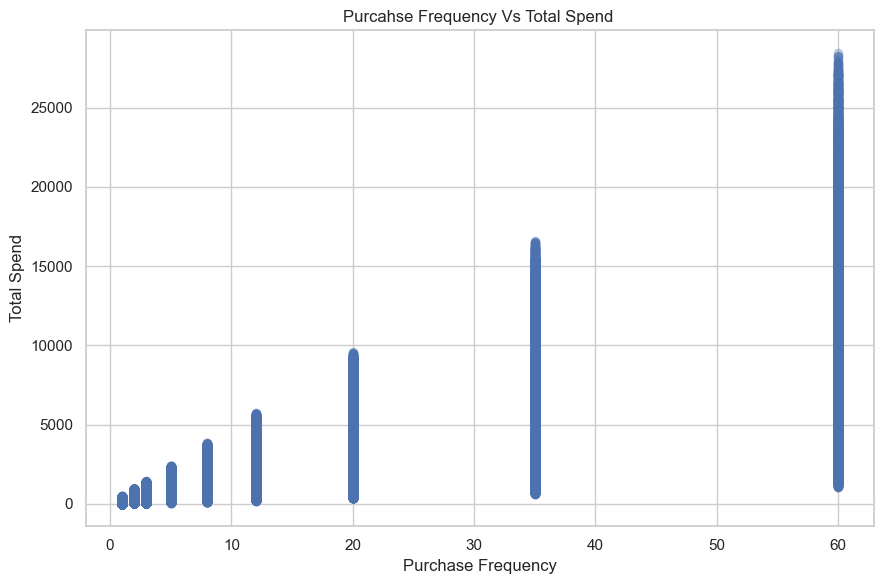

In [26]:
plt.figure(figsize=(9,6))
plt.scatter(
    df["purchase_frequency"],
    df["total_spent"],
    alpha=0.3
)

plt.title("Purcahse Frequency Vs Total Spend ")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spend")

plt.tight_layout()
plt.show()

### Insight

The scatter plot helps visualizde the relationship between how frequency customers purchase and their total spending.
Customers with higher purchase frequency generally have the potential to contribute more to overall customer value.

### Business Implication

The business can identify the customers who show high purchase frequency and high spending behaviour as valuable customer .
These customets may deserve prority in retention and loyalty strategies.

## Distribution Of Customer Spending 

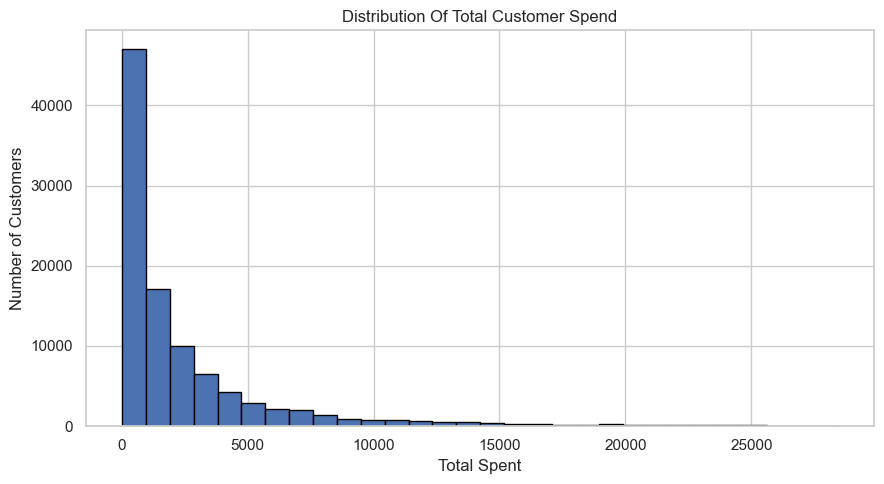

In [27]:
plt.figure(figsize=(9,5))
plt.hist(
    df["total_spent"],
    bins=30,
    edgecolor="black"
    )
plt.title("Distribution Of Total Customer Spend")
plt.xlabel("Total Spent")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


### Insight

The spending distribution shows how customer value is distributed across the dataset.
The histogram helps identify whether most customers are concentrated within a particualr spending range and wether high-spending customers represent  a small portipon of the customer basis.

### Business Implication

High-spending customers should be monitored carefully because lossing them may have a greater financial impact than losing low value customwers.

## Loyalty Score And Customer Churn

In [30]:
df["loyalty_bucket"]=pd.cut(
    df["loyalty_score"],
    bins=[-1,20,40,60,80,100],
    labels=[
        "0-20","21-40","41-60","61-80","81-100"
    ]
)
        

In [31]:
loyalty_churn = (
    df.groupby(
        "loyalty_bucket",
               observed=False)
    ["churn_flag"].mean()*100
)

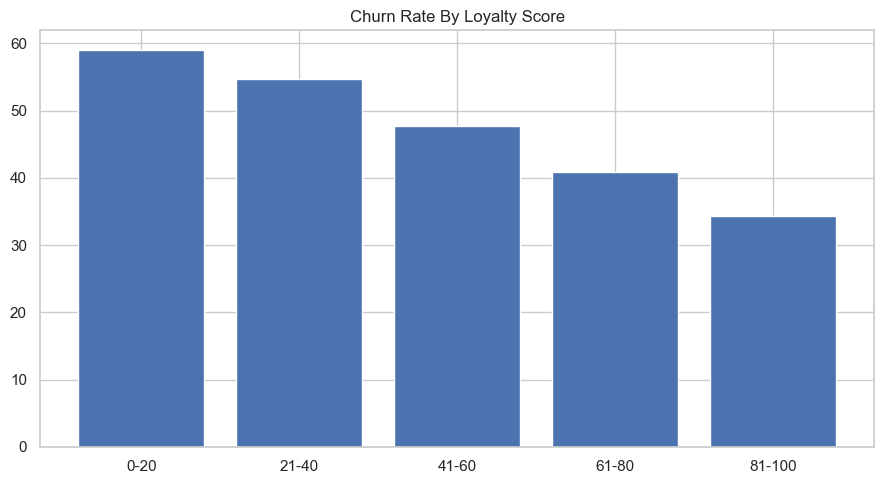

In [32]:
plt.figure(figsize=(9,5))
plt.bar(
    loyalty_churn.index.astype(str),
    loyalty_churn.values
)
plt.title("Churn Rate By Loyalty Score")
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()

### Insight
Churn behaviour varies across different loyalty score ranges. This suggests that loyalty can provide additional context when analysing customer churn.
However, loyalty score should not be considered in isolation because customer behaviour can also be influenced by factors such as recency, engagement and spending.
### Business Implication
The business can monitor customers with lower loyalty scores alongside other behavioural indicators.
Loyalty programmes may be more useful when focused on customers showing multiple signs of disengagement rather than relying on loyalty score alone

## Customer Engagement and Churn 

In [33]:
df["engagement_bucket"]=pd.cut(
    df["engagement_score"],
    bins=[-1,20,40,60,80,100],
    labels=[
    "0-20","21-40","41-60","61-80","81-100"]
)

In [34]:
engagement_churn=(
    df.groupby(
        "engagement_bucket",
               observed=False
              )["churn_flag"]
.mean()*100
)

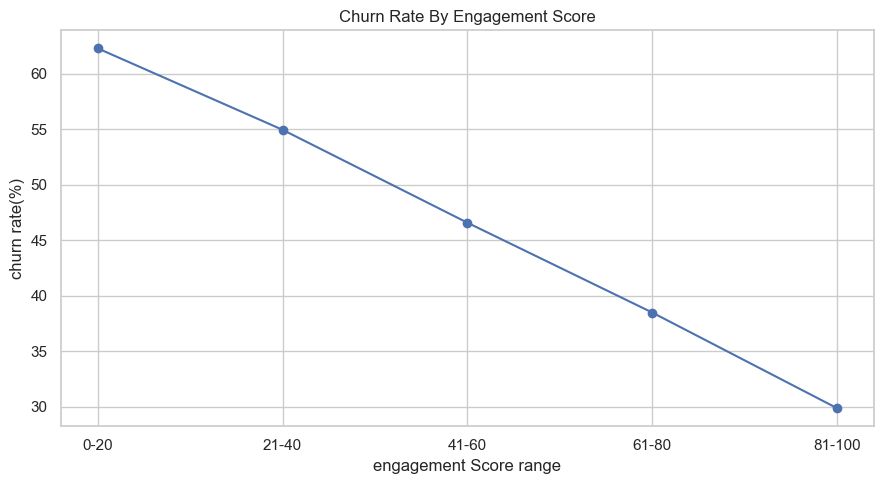

In [35]:
plt.figure(figsize=(9,5))
plt.plot(
    engagement_churn.index.astype(str),
    engagement_churn.values,
    marker="o"
)

plt.title("Churn Rate By Engagement Score")
plt.xlabel("engagement Score range")
plt.ylabel("churn rate(%)")

plt.grid(True)
plt.tight_layout()
plt.show()

### Insight
Churn behaviour differs across customer engagement levels. Engagement therefore provides an additional behavioural signal for understanding customer churn.
Customers showing lower engagement can be monitored together with other indicators such as recency, cart abandonment and loyalty.
### Business Implication
The business can monitor changes in customer engagement and identify customers whose activity is declining.
These customers can be targeted with relevant communication, personalized recommendations or re-engagement campaigns before prolonged inactivity develops.

## Comparing Churn And Retained Customer Behaviour

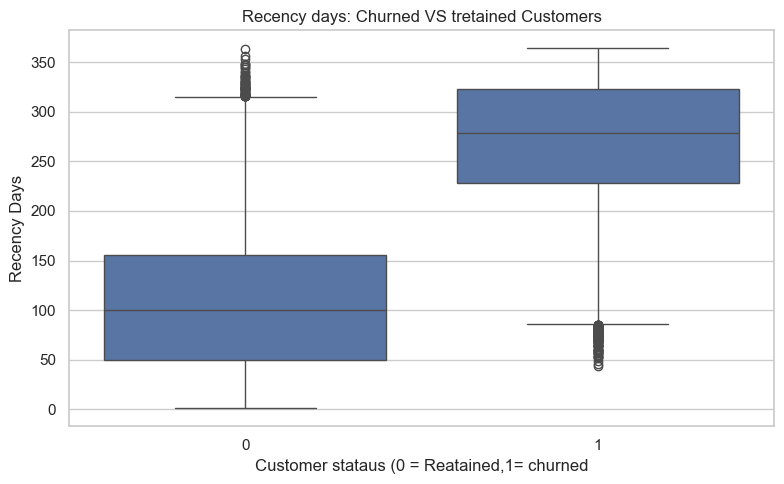

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_flag",
    y="recency_days"
)
plt.title("Recency days: Churned VS tretained Customers")
plt.xlabel("Customer stataus (0 = Reatained,1= churned")
plt.ylabel("Recency Days")
plt.tight_layout()
plt.show()


### Insight 
The Distribution of recency days differs between retained and churned customer.
The comaprision provides further evidence that customers inactivity is closely associated with churn behaviour.
### Business Implication

Monitoring changes in customer acttivity can help business identify potentialchurn risk before the customer bcomes completly inactive.

# Key Findings

### 1. Churn is a Significant Business Issue

The analysis shows that 46.22% of customers have churned, indicating that customer retention is an important business concern.

### 2. Customer Inactivity is Strongly Associated with Churn

Customers with a longer time since their last purchase show higher churn rates. This makes recency one of the most useful behavioural indicators for identifying customers who may be at risk of churn.

### 3. Higher Cart Abandonment is Associated with Higher Churn

Customers with higher cart abandonment rates tend to show higher churn rates. This indicates that repeated abandonment may be an important signal within the customer purchasing journey.

This relationship shows an association and does not establish that cart abandonment directly causes churn.

### 4. Behavioural Indicators Provide More Insight Than Customer Segment Alone

Churn rates across customer segments are relatively close, ranging from 45.93% for Loyal customers to 46.67% for VIP customers. This suggests that customer segment alone may not be sufficient for identifying customers at risk.

Behavioural indicators such as recency, engagement and cart abandonment provide additional context.

### 5. Customer Value Matters When Planning Retention

The spending analysis shows that customers differ considerably in their contribution to overall customer value. Therefore, retention efforts should consider both churn-related behaviour and the potential financial value of customers.

### 6. Loyalty and Engagement Should Be Considered Alongside Other Signals

Churn behaviour varies across loyalty and engagement levels. These measures can provide useful additional context when combined with indicators such as recency, spending and cart abandonment rather than being used in isolation.

# Business Recommendations

### 1. Use Recency-Based Retention Campaigns

Monitor customers based on the number of days since their last purchase.

- Recently inactive customers → reminder or re-engagement communication
- Moderately inactive customers → targeted offers or personalized recommendations
- Long-term inactive customers → win-back campaigns

The timing and effectiveness of these interventions should be validated through testing.

### 2. Address High Cart Abandonment

Customers with repeated cart abandonment can be targeted with:

- Cart reminder campaigns
- Checkout experience improvements
- Clear pricing and delivery information
- Personalized product reminders

The business should also investigate whether specific stages of the purchasing journey are creating friction.

### 3. Monitor Declining Customer Engagement

Track changes in customer engagement and identify customers whose activity is declining. These customers can be approached with relevant communication or product recommendations before they become completely inactive.

### 4. Combine Multiple Behavioural Signals

Retention decisions should not rely on a single variable. Recency, engagement, loyalty, cart abandonment and spending can be considered together to build a more complete view of customer behaviour.

### 5. Consider Customer Value in Retention Planning

High-spending customers may have a greater financial impact if lost. Retention efforts can therefore consider both the customer's churn-related behaviour and their contribution to customer value.

### 6. Measure the Effectiveness of Retention Strategies

Retention campaigns should be evaluated using measurable business metrics such as:

- Reactivation Rate
- Repeat Purchase Rate
- Customer Retention Rate
- Incremental Revenue